<a href="https://colab.research.google.com/github/Aswathyak26/Aswathyak/blob/main/Classification_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data1 = pd.read_csv(r'/content/titanic_dataset.csv',index_col='PassengerId')
data1

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [3]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [4]:
data1.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
data1['Survived'].nunique() #Binary Classification Problem
#Target Survived

2

In [6]:
data1['Survived'].value_counts(normalize = True) #not a balanced dataset.

,proportion
Survived,
0,0.616162
1,0.383838


In [7]:
# Duplicate Rows
print("Duplicate Rows:", data1.duplicated().sum())
# Remove duplicate rows
data1 = data1.drop_duplicates()

Duplicate Rows: 0


In [8]:
# Duplicate Columns
duplicate_columns = data1.columns[data1.T.duplicated()]
print("Duplicate Columns:")
print(duplicate_columns)
# Remove duplicate columns
data1 = data1.loc[:, ~data1.T.duplicated()]

Duplicate Columns:
Index([], dtype='object')


In [9]:
print("\nMissing Values :")
data1.isnull().sum()


Missing Values :


,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


In [10]:
# Drop unwanted column
df1= data1.drop(columns=['Cabin']) #This column is removed because of large number of missing value.

In [11]:
# Missing numerical columns
missing_num_cols = [col for col in df1.select_dtypes(include=['number']).columns if df1[col].isnull().sum() > 0]

print("Missing Numerical Columns:\n", missing_num_cols)

Missing Numerical Columns:
 ['Age']


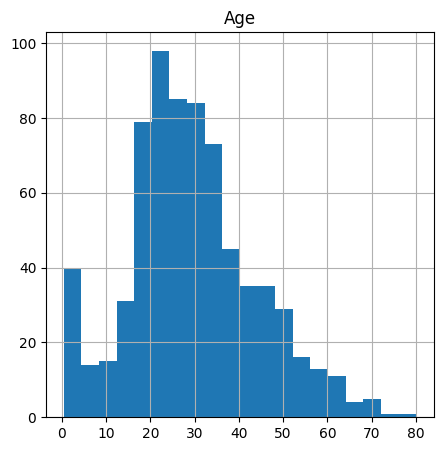

In [12]:
df1[missing_num_cols].hist(figsize=[5, 5], bins=20)
plt.show()

In [13]:
# 1.  Missing Continuous numerical features - Median
# Median is used because Age feature is skewed
df1['Age'] = df1['Age'].fillna(df1['Age'].median())

In [14]:
#2. Missing categorical features
# Categorical missing values filled using mode because mode represents the most frequent category
missing_cat_cols = [col for col in df1.select_dtypes(include=['object']).columns
                   if df1[col].isnull().sum() > 0]
print("\nMissing Categorical Columns:\n", missing_cat_cols)


Missing Categorical Columns:
 ['Embarked']


In [15]:
df1['Embarked'] = df1['Embarked'].fillna(df1['Embarked'].mode()[0])

In [16]:
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df1.select_dtypes(include=['object']).columns

print('Numerical Columns:\n', numerical_cols)
print('\nCategorical Columns:\n', categorical_cols)

Numerical Columns:
 Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Categorical Columns:
 Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


In [17]:
for col in numerical_cols:
    print(col)
    print("Unique values :", df1[col].nunique())
    print()

Survived
Unique values : 2

Pclass
Unique values : 3

Age
Unique values : 88

SibSp
Unique values : 7

Parch
Unique values : 7

Fare
Unique values : 248



In [18]:
# Survived is the target variable
# SibSp and Parch are discrete but we use IQR capping here.
# 'Name', 'Sex', 'Ticket', 'Embarked' are categorical variables
# Pclass is ordinal category column
columns_to_clean_outliers = ['Age', 'SibSp', 'Parch', 'Fare']

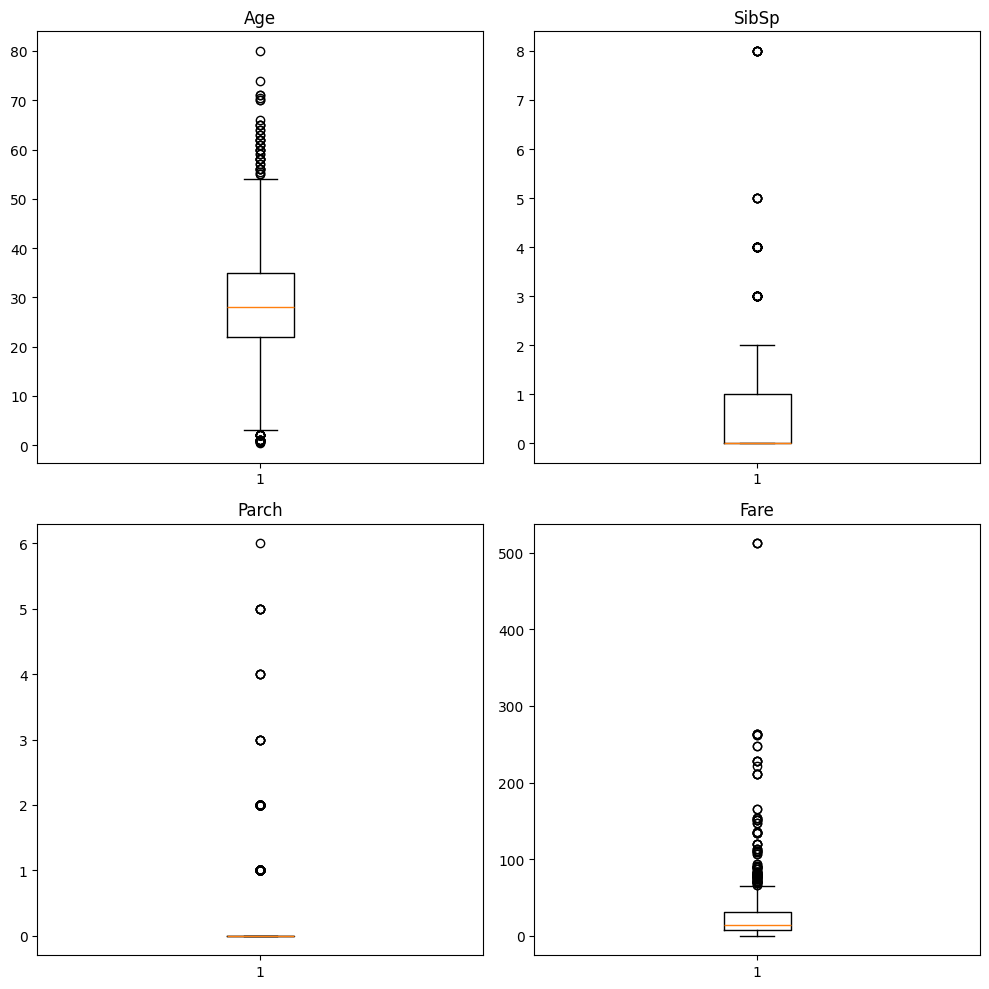

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
i = 0 # Start a manual counter at index 0
for col in columns_to_clean_outliers:
    axes[i].boxplot(df1[col])
    axes[i].set_title(col)
    i = i + 1  # Manually move to the next subplot position for the next column
plt.tight_layout()
plt.show()

In [20]:
# Based on boxplot analysis
# Therefore, IQR-based outlier treatment was applied only to those columns.
outliers = ['Age', 'SibSp', 'Parch', 'Fare']
for col in outliers:
    Q1 = np.percentile(df1[col],25)
    Q3 = np.percentile(df1[col],75)
    IQR = Q3 - Q1
    lwr_lim = Q1 - 1.5 * IQR
    upr_lim = Q3 + 1.5 * IQR
    df1[col] = df1[col].clip(lower=lwr_lim, upper=upr_lim) #IQR Capping done.
print("\nShape After Outlier Removal:", df1.shape)



Shape After Outlier Removal: (891, 10)


In [21]:
for col in categorical_cols :
    print(col)
    print("Unique values :", df1[col].nunique())
    print()

Name
Unique values : 891

Sex
Unique values : 2

Ticket
Unique values : 681

Embarked
Unique values : 3



In [22]:
df1['Sex'].unique()

array(['male', 'female'], dtype=object)

In [23]:
#label mapping
condition_mapping = {'male': 0,'female':1}
df1['Sex'] = df1['Sex'].map(condition_mapping)

In [24]:
df1['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [25]:
#Nominal category -one hot Encoding
# no order among categories, therefore One-Hot Encoding is more suitable than label mapping.
df1 = pd.get_dummies(df1, columns=['Embarked'], dtype='int')
#Since the models performed slightly better without drop_first=True, that method was selected for the final analysis.

In [26]:
df1.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",0,22.0,1.0,0,A/5 21171,7.2500,0,0,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1.0,0,PC 17599,65.6344,1,0,0
3,1,3,"Heikkinen, Miss. Laina",1,26.0,0.0,0,STON/O2. 3101282,7.9250,0,0,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1.0,0,113803,53.1000,0,0,1
5,0,3,"Allen, Mr. William Henry",0,35.0,0.0,0,373450,8.0500,0,0,1


In [27]:
x = df1.drop(['Survived','Name','Ticket'], axis=1) # 'Name','Ticket' are dropped here.
y = df1['Survived'] #'Survived' is the target feature

In [28]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
x = std_scaler.fit_transform(x)
x = pd.DataFrame(x)
#scaling mainly mattered for SVM and KNN, while tree-based models and most others remained largely unaffected.

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state = 42)

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score,recall_score, f1_score

In [31]:
def evaluate_model(model):

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)


    print("Accuracy :", round(accuracy,6))
    print("Precision:", round(precision,6))
    print("Recall   :", round(recall,6))
    print("F1 Score :", round(f1,6))
    print("\nconfusion matrix: \n", cm)
    print(" y_pred :\n",  y_pred )

In [32]:
print("LOGISTIC REGRESSION")
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=100)
evaluate_model(lr)

LOGISTIC REGRESSION
Accuracy : 0.793296
Precision: 0.753425
Recall   : 0.743243
F1 Score : 0.748299

confusion matrix: 
 [[87 18]
 [19 55]]
 y_pred :
 [0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


In [33]:
from sklearn.naive_bayes import GaussianNB
print("NAIVE BAYES")
nb_classifier = GaussianNB()
evaluate_model(nb_classifier)

NAIVE BAYES
Accuracy : 0.776536
Precision: 0.697674
Recall   : 0.810811
F1 Score : 0.75

confusion matrix: 
 [[79 26]
 [14 60]]
 y_pred :
 [0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 1
 0 1 0 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 1 1 1]


In [34]:
from sklearn.neighbors import KNeighborsClassifier
metric_k = [] #create a empty list for k accuracy values
neighbors = np.arange(3,16)
for k in neighbors:
    classifier = KNeighborsClassifier(n_neighbors = k, metric = 'euclidean')
    classifier = classifier.fit(x_train, y_train)
    y_pred_knn = classifier.predict(x_test)
    acc = accuracy_score(y_test, y_pred_knn)
    metric_k.append(acc)
metric_k

[0.7932960893854749,
 0.7653631284916201,
 0.8268156424581006,
 0.8156424581005587,
 0.8324022346368715,
 0.7932960893854749,
 0.8156424581005587,
 0.7932960893854749,
 0.8156424581005587,
 0.8100558659217877,
 0.8100558659217877,
 0.7988826815642458,
 0.8212290502793296]

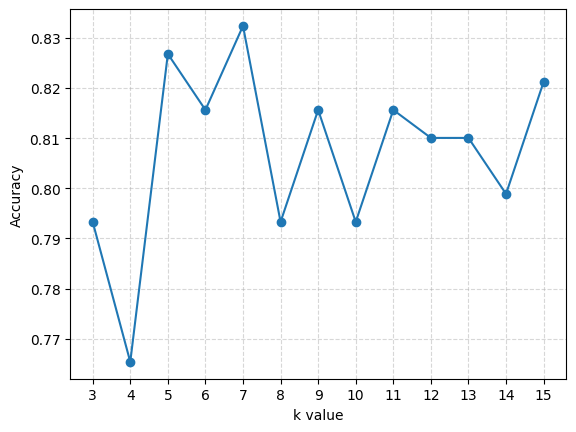

In [35]:
plt.plot(neighbors,metric_k, 'o-')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.xticks(neighbors)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [36]:
print("KNN")
knn= KNeighborsClassifier(n_neighbors = 7, metric = 'euclidean')  #took k = 7 beacuse it has highest accuracy
evaluate_model(knn)
#Although GridSearchCV selected Manhattan distance as the optimal metric based on cross-validation performance,
#the manually selected Euclidean-distance model achieved slightly higher accuracy on the test dataset.
#KNN performs significantly better with StandardScaler because it relies on distance calculations, making feature scaling essential.

KNN
Accuracy : 0.832402
Precision: 0.823529
Recall   : 0.756757
F1 Score : 0.788732

confusion matrix: 
 [[93 12]
 [18 56]]
 y_pred :
 [0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1]


In [37]:
from sklearn.svm import SVC
print("SVM")
svm = SVC(kernel='poly')
evaluate_model(svm)
#Three SVM kernels (Linear, RBF, and Polynomial) were tested.
#The Polynomial kernel achieved the highest Accuracy and F1-score
#SVM is highly sensitive to feature scaling, and without StandardScaler it can completely fail by predicting only one class.

SVM
Accuracy : 0.815642
Precision: 0.825397
Recall   : 0.702703
F1 Score : 0.759124

confusion matrix: 
 [[94 11]
 [22 52]]
 y_pred :
 [0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1]


In [38]:
from sklearn.tree import DecisionTreeClassifier
print("DECISION TREE")
dt = DecisionTreeClassifier(random_state=42,class_weight='balanced')
evaluate_model(dt)
#Because the dataset is imbalanced, the default decision tree was biased toward the majority class.
#Using class_weight='balanced' helping the model reduce bias toward the majority class and improving recall.

DECISION TREE
Accuracy : 0.782123
Precision: 0.716049
Recall   : 0.783784
F1 Score : 0.748387

confusion matrix: 
 [[82 23]
 [16 58]]
 y_pred :
 [0 1 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1
 1 1 0 0 0 0 0 1 0 1 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 1
 0 1 1 0 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1
 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1]


In [39]:
from sklearn.ensemble import RandomForestClassifier
print("RANDOM FOREST")
rf = RandomForestClassifier(random_state=42,max_depth= 10, min_samples_leaf= 1, min_samples_split= 10, n_estimators= 100,class_weight='balanced')
evaluate_model(rf)
#Multiple Random Forest models were trained using different hyperparameters and class weighting strategies.


RANDOM FOREST
Accuracy : 0.854749
Precision: 0.842857
Recall   : 0.797297
F1 Score : 0.819444

confusion matrix: 
 [[94 11]
 [15 59]]
 y_pred :
 [0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1]


In [40]:
def e_model(model):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

In [41]:
results = pd.DataFrame(columns=['Accuracy','Precision','Recall','F1'])
results.loc['Logistic Regression'] = e_model(LogisticRegression(max_iter=100))
results.loc['Naive Bayes'] = e_model(GaussianNB())
results.loc['KNN'] = e_model(KNeighborsClassifier(n_neighbors = 7, metric = 'euclidean'))
results.loc['SVM'] = e_model(SVC(kernel='poly'))
results.loc['Decision Tree'] = e_model(DecisionTreeClassifier(random_state=42,class_weight='balanced') )
results.loc['Random Forest'] = e_model(RandomForestClassifier(random_state=42,max_depth= 10, min_samples_leaf= 1, min_samples_split= 10, n_estimators= 100,class_weight='balanced'))
print(results)

                     Accuracy  Precision    Recall        F1
Logistic Regression  0.793296   0.753425  0.743243  0.748299
Naive Bayes          0.776536   0.697674  0.810811  0.750000
KNN                  0.832402   0.823529  0.756757  0.788732
SVM                  0.815642   0.825397  0.702703  0.759124
Decision Tree        0.782123   0.716049  0.783784  0.748387
Random Forest        0.854749   0.842857  0.797297  0.819444


In [43]:
# Among all models, Random Forest performed the best overall.
# It achieved the highest Accuracy (85.47%), Precision (84.29%), and F1-score (81.94%),
# while maintaining a strong Recall of 79.73% (second only to Naive Bayes at 81.08%).
# Random Forest provides the best balance between correctly identifying survivors
# and maintaining overall prediction reliability.
# Therefore, Random Forest is selected as the final model for this classification problem.